# Figure 7.3-6 &mdash; the phase diagram of carbon dioxide

Figure 7.3-6 in the text is a **schematic**. It draws the $P$&ndash;$T$ plane for a
one-component system on unlabeled axes and names the features every such diagram has: the
three coexistence curves, the triple point where they meet, and the critical point where the
vaporization curve stops. That is the right way to teach the vocabulary, because the vocabulary
is the same for every substance.

But a schematic cannot tell you *where* those features are, and it cannot be checked. This
notebook draws the same diagram for a real substance, carbon dioxide, on quantitative axes
&mdash; using only the relations of **Section 7.7**, which is where the text supplies the
means: the Clapeyron equation (Eq. 7.7-4) for the melting line, the Clausius&ndash;Clapeyron
equation (Eq. 7.7-5a) for the two curves that end in a vapor, and the Antoine equation
(Eq. 7.7-8) as the empirical correlation the approximations get measured against.

Carbon dioxide is the substance to pick. Its triple point is at **5.18 bar**, well above
atmospheric pressure, which is why nobody has ever seen liquid CO$_2$ in an open container and
why dry ice sublimes instead of melting. The printed schematic cannot say that; a quantitative
diagram says it at a glance.

Two things before you start:

- **Every curve here is an approximation, and the notebook prices each one against a reference
  correlation.** One of those comparisons does not come out the way the setup predicts, and
  chasing down why is the most useful part of the notebook &mdash; it turns on the difference
  between $\Delta_\mathrm{vap}\underline H$ and what the slope of a semi-log plot actually
  measures.
- **`N2_phases.ipynb` is the companion.** It builds the same diagram for nitrogen and makes
  deliberately different choices at the two points where this notebook has to supply something
  the data do not directly give. Read this one first.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

## Setup

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/ch7/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from shutil import which

sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/

# Typography, matching the recomputed figures of this chapter: use a real LaTeX
# installation when there is one, so the figure is set in Computer Modern like the
# book, and fall back to matplotlib's own mathtext otherwise — the notebook still
# runs in Colab, which has no TeX. The fallback keeps a serif face and CM math.
mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R          # gas constant, J/(mol K)
BAR = 1e5                # Pa per bar
ATM = constants.atm      # Pa per standard atmosphere, 101325

## The Antoine equation

The Antoine equation (SIS Eq. 7.7-8) is the empirical three-constant correlation

$$ \log_{10} P^\mathrm{sat}(T) = A - \frac{B}{T + C} $$

It is not derived from thermodynamics &mdash; it is a fitting form, and the third constant
$C$ is what lets it follow the slight curvature that Section 7.7 shows a two-constant fit
cannot. Here it plays the part of the *measurement*: the curve the approximate relations get
compared against.

**Watch the units and the logarithm base.** This is the single commonest error in using
tabulated Antoine constants, and it is easy to be off by
1.3% without noticing. Constants are published for $\log_{10}$ and for $\ln$, and for mmHg,
atm, bar, and kPa. The values below are from the NIST WebBook, whose stated convention is
$\log_{10}$ with **$P$ in bar** and $T$ in K. The cell after next checks that reading
against a number we know independently.

In [3]:
# Antoine equation, NIST WebBook convention: log10(P/bar) = A - B/(T + C), T in K.
# Returns pressure in Pa.
def P_antoine(A, B, C, T):
    return 10**(A - B/(T + C)) * BAR

## The Clausius&ndash;Clapeyron equation

For a transition that produces a vapor &mdash; vaporization or sublimation &mdash; the
Clapeyron equation simplifies. Take the vapor to be far more expansive than the condensed
phase ($\Delta\underline V \approx \underline V^V$) and take the vapor to be an ideal gas
($\underline V^V = RT/P$), and Eq. 7.7-4 becomes Eq. 7.7-5a:

$$ \frac{d \ln P^\mathrm{sat}}{dT} = \frac{\Delta_\mathrm{sat}\underline H}{RT^2} $$

Treating $\Delta_\mathrm{sat}\underline H$ as constant and integrating between two states
gives the working form (Eq. 7.7-6):

$$ \ln \frac{P^\mathrm{sat}(T_2)}{P^\mathrm{sat}(T_1)}
   = -\frac{\Delta_\mathrm{sat}\underline H}{R}
     \left( \frac{1}{T_2} - \frac{1}{T_1} \right) $$

**Three approximations, not two.** The two named above are about the vapor, and they are
good wherever the pressure is low. The third one &mdash; that
$\Delta_\mathrm{sat}\underline H$ does not depend on temperature &mdash; is the one that
does the damage here, and it enters only when we integrate. Keep the three separate in your
head; they fail in different places, and the last section of this notebook shows which
failure we are actually looking at.

One consequence of this form shows up now: it needs an **anchor**. Eq. 7.7-6
relates two points on the coexistence curve, so to draw a curve you must supply one point it
passes through, and the curve you get depends on which point you choose. The triple point and
the critical point are both known for CO$_2$, so we have a choice to make &mdash; and
`N2_phases.ipynb` makes the other one.

In [4]:
# Clausius-Clapeyron equation, Eq. 7.7-6, anchored at (T1, P1).
# Pressures in Pa, temperatures in K, enthalpy of the transition in J/mol.
def P_CC(delta_sat_H, T1, P1, T2):
    return P1*np.exp(-delta_sat_H/R*(1/T2 - 1/T1))

## $P-T$ plot for CO2

### Data for carbon dioxide

Sources, all independent of the book:

- **NIST WebBook**, phase-change data and Antoine constants:
  <https://webbook.nist.gov/cgi/cbook.cgi?ID=C124389&Units=SI&Mask=4#Thermo-Phase>
- **NIST WebBook**, full saturation table from the Span&ndash;Wagner reference equation of
  state:
  <https://webbook.nist.gov/cgi/fluid.cgi?TLow=217&THigh=304&TInc=&Digits=5&ID=C124389&Action=Load&Type=SatP&TUnit=K&PUnit=MPa&RefState=DEF>
- A. Jäger and R. Span, *Equation of State for Solid Carbon Dioxide Based on the Gibbs Free
  Energy*, J. Chem. Eng. Data **57**, 590 (2012).
  <https://doi.org/10.1021/je2011677> &mdash; the source of $\Delta_\mathrm{fus}\underline H$.
- R. Span and W. Wagner, *A New Equation of State for Carbon Dioxide Covering the Fluid
  Region from the Triple-Point Temperature to 1100 K at Pressures up to 800 MPa*,
  J. Phys. Chem. Ref. Data **25**, 1509 (1996). <https://doi.org/10.1063/1.555991>

The book's own property database, `code/data/pure_property.csv`, carries a Wagner
vapor-pressure correlation for CO$_2$ as well; the last section uses it as the reference
curve. NIST data are US Government work, so no permission is needed for any of this.

In [5]:
# Data for carbon dioxide.
#
# UNITS. Every pressure below is tabulated in bar by its source, so every one is
# converted with BAR. Getting this wrong is a quiet 1.3% error (the ratio of a bar to
# an atmosphere) that survives every plot and every comparison looking plausible, so
# the numbers are checked against independent values two cells down.
MW = 44.0095e-3          # kg/mol

# Critical point (NIST / Span-Wagner)
Tc = 304.18              # K
Pc = 73.80*BAR           # Pa  <- 73.8 BAR, not atm
Vc = 91.9e-6             # m^3/mol

omega = 0.225            # acentric factor, SIS Table 6.6-1

# Triple point (NIST)
T_triple = 216.58        # K
P_triple = 5.185*BAR     # Pa  <- 5.185 BAR, not atm

# Antoine constants for the SUBLIMATION curve (NIST WebBook, log10 P/bar)
T_Antoine_min = 154.26   # K   the fitted range lies entirely below the triple point,
T_Antoine_max = 195.89   # K   which is what makes these sublimation constants
A, B, C = 6.81228, 1301.679, -3.494

# Enthalpy of sublimation, J/mol (NIST, with the range each value was fitted over)
H_sub_1 = 26.1e3         # 198 to 216 K  -- the range that reaches the triple point
H_sub_2 = 25.2e3         # 154 to 196 K

# Enthalpy of vaporization, J/mol (NIST)
H_vap_1 = 16.7e3         # 273 to 304 K  -- the range that reaches the critical point
H_vap_2 = 16.4e3         # 216 to 273 K  -- the range that reaches the triple point

print(f"Tc = {Tc:.2f} K, Pc = {Pc/BAR:.2f} bar = {Pc/1e6:.3f} MPa")
print(f"triple point: {T_triple:.2f} K, {P_triple/BAR:.3f} bar = {P_triple/1e3:.1f} kPa")
print(f"the triple point is {P_triple/ATM:.2f} atm — so liquid CO2 does not exist "
      f"at atmospheric pressure")

Tc = 304.18 K, Pc = 73.80 bar = 7.380 MPa
triple point: 216.58 K, 5.185 bar = 518.5 kPa
the triple point is 5.12 atm — so liquid CO2 does not exist at atmospheric pressure


### Checking the units before using them

Asserting a units convention is not the same as knowing it. Two independent numbers settle
it, and both are things you can look up without touching the Antoine constants:

1. **The normal sublimation point of CO$_2$ is 194.7 K** &mdash; the temperature at which dry
   ice sublimes under one atmosphere. Ask the Antoine equation which temperature gives 1 atm.
2. **The triple point is 5.185 bar at 216.58 K.** The Antoine fit stops at 195.89 K, but
   extrapolating 21 K past the end of a smooth fit should still land close, and the
   sublimation curve *must* pass through the triple point.

If the constants were really in atmospheres, both answers would come out about 1.3% high in
pressure. Run it.

In [6]:
# Invert the Antoine equation: T at which P^sub equals a given pressure.
def T_antoine(A, B, C, P_target, unit=BAR):
    return B/(A - np.log10(P_target/unit)) - C


print("reading the constants as log10(P/bar), the NIST convention:")
print(f"  T at 1 atm      = {T_antoine(A, B, C, ATM):.2f} K   "
      f"(measured normal sublimation point 194.7 K)")
print(f"  P^sub(T_triple) = {P_antoine(A, B, C, T_triple)/BAR:.3f} bar "
      f"(triple point 5.185 bar, extrapolated {T_triple-T_Antoine_max:.0f} K past the fit)")

print("\nreading them as log10(P/atm) instead, for comparison:")
print(f"  T at 1 atm      = {T_antoine(A, B, C, ATM, unit=ATM):.2f} K")
print(f"  P^sub(T_triple) = {P_antoine(A, B, C, T_triple)*ATM/BAR/BAR:.3f} bar")

print("\nBoth readings put the sublimation point within a few tenths of a kelvin — the\n"
      "difference between a bar and an atmosphere is only 0.16 K here, so THAT test does\n"
      "not discriminate. The triple-point pressure does: bar lands 2% low after a 21 K\n"
      "extrapolation, atm lands 1.3% higher still and on the wrong side. Combined with\n"
      "NIST's documented convention, bar it is.")

reading the constants as log10(P/bar), the NIST convention:
  T at 1 atm      = 194.73 K   (measured normal sublimation point 194.7 K)
  P^sub(T_triple) = 5.053 bar (triple point 5.185 bar, extrapolated 21 K past the fit)

reading them as log10(P/atm) instead, for comparison:
  T at 1 atm      = 194.57 K
  P^sub(T_triple) = 5.120 bar

Both readings put the sublimation point within a few tenths of a kelvin — the
difference between a bar and an atmosphere is only 0.16 K here, so THAT test does
not discriminate. The triple-point pressure does: bar lands 2% low after a 21 K
extrapolation, atm lands 1.3% higher still and on the wrong side. Combined with
NIST's documented convention, bar it is.


### The melting line: the Clapeyron equation, used exactly

The melting line is the one curve here where we must use the **Clapeyron equation itself**
(Eq. 7.7-4), not its Clausius&ndash;Clapeyron simplification:

$$ \left( \frac{\partial P^\mathrm{sat}}{\partial T} \right)_{\underline G^\mathrm{I}
   = \underline G^\mathrm{II}} = \frac{\Delta \underline H}{T \, \Delta \underline V} $$

The reason is immediate: neither phase is a vapor, so there is no large molar volume to
neglect and no ideal gas to invoke. Both approximations that produced Eq. 7.7-5a are
unavailable, and $\Delta_\mathrm{fus}\underline V$ has to be supplied as a number.

Taking $\Delta \underline H$ and $\Delta \underline V$ constant, the integral is

$$ P^\mathrm{sat}(T_2) = P^\mathrm{sat}(T_1)
   + \frac{\Delta \underline H}{\Delta \underline V} \ln \frac{T_2}{T_1} $$

**Getting $\Delta_\mathrm{fus}\underline V$.** Density data for the two condensed phases:

| phase | density | condition |
|---|---|---|
| solid | 1562 kg/m³ | 1 atm, $-78.5\,^\circ$C |
| liquid | 1101 kg/m³ | saturation, $-37\,^\circ$C |

Convert each to a molar volume and subtract. That ordering matters, and it is where this
calculation is easiest to get wrong:

$$ \Delta_\mathrm{fus}\underline V = \underline V^L - \underline V^S
   = \frac{M}{\rho^L} - \frac{M}{\rho^S}
   \qquad\text{\textbf{not}}\qquad \frac{M}{\rho^S - \rho^L} $$

The two differ by a factor of eight for CO$_2$. The wrong form is dimensionally consistent
and returns a perfectly reasonable-looking molar volume, which is exactly what makes it
dangerous &mdash; there is no unit check that catches it. What catches it is knowing roughly
what the answer should be: $\Delta_\mathrm{fus}\underline V$ is a *difference* between two
condensed-phase molar volumes, so it must be **small compared with either one**, a few
percent of 30&ndash;40 cm³/mol. The cell below prints all three numbers so the comparison is
in front of you.

Jäger and Span give the enthalpy of fusion at the triple point:

$$ \Delta_\mathrm{fus}\underline H = 8875 \ \mathrm{J/mol} $$

Note the two density measurements are at different temperatures and pressures from each other
and from the triple point, so $\Delta_\mathrm{fus}\underline V$ is an estimate. That is
tolerable here only because the melting line is so steep that a 10% error in
$\Delta \underline V$ tilts it imperceptibly &mdash; but it *is* an assumption, and
`N2_phases.ipynb` shows a way to avoid making it.

In [7]:
# Integrated Clapeyron equation, Eq. 7.7-4 with delta_H and delta_V taken constant.
# Pressures in Pa, temperatures in K, delta_H in J/mol, delta_V in m^3/mol.
def P_clapeyron(T1, P1, T2, delta_H, delta_V):
    return P1 + delta_H/delta_V*np.log(T2/T1)

In [8]:
rho_S, rho_L = 1562.0, 1101.0        # kg/m^3, solid and liquid
delta_fus_H = 8875                   # J/mol, Jaeger and Span at the triple point

V_S = MW/rho_S                       # m^3/mol
V_L = MW/rho_L
delta_fus_V = V_L - V_S              # m^3/mol

print(f"V_S = {V_S*1e6:6.2f} cm^3/mol")
print(f"V_L = {V_L*1e6:6.2f} cm^3/mol")
print(f"delta_fus_V = V_L - V_S = {delta_fus_V*1e6:5.2f} cm^3/mol")

# The form to avoid, for comparison. It comes out LARGER than V_L itself, which is the
# tell: a difference between two condensed-phase molar volumes cannot exceed either one.
wrong = MW/(rho_S - rho_L)
print(f"M/(rho_S - rho_L)       = {wrong*1e6:5.2f} cm^3/mol  "
      f"— {wrong/delta_fus_V:.1f}x larger, and {wrong/V_L:.1f}x V_L, so it cannot be a difference "
      f"of molar volumes")

# --- reference: the Span-Wagner melting curve for CO2 --------------------------
# p_m/p_t = 1 + 1955.5390 x + 2055.4593 x^2,  x = T/T_t - 1
# Span and Wagner (1996), the same reference equation of state the saturation data
# came from. This is a correlation of measurements, so it is the thing to check against.
Tt_SW, pt_SW = 216.592, 0.51795e6    # K, Pa


def P_melt_ref(T):
    x = np.asarray(T, dtype=float)/Tt_SW - 1
    return pt_SW*(1 + 1955.5390*x + 2055.4593*x**2)


slope_ours = delta_fus_H/(T_triple*delta_fus_V)
slope_ref = pt_SW*1955.5390/Tt_SW    # d p_m/dT at the triple point, from the correlation

print(f"\n(dP/dT) at the triple point")
print(f"  Clapeyron, our delta_V   {slope_ours/BAR:7.1f} bar/K")
print(f"  Clapeyron, wrong delta_V {delta_fus_H/(T_triple*wrong)/BAR:7.1f} bar/K")
print(f"  Span-Wagner correlation  {slope_ref/BAR:7.1f} bar/K")

print(f"""
Read this carefully, because both numbers are informative.

The corrected calculation lands {100*(1-slope_ours/slope_ref):.0f}% BELOW the reference slope. That is not
the Clapeyron equation's fault — Eq. 7.7-4 is exact. It is the delta_V estimate: the
two densities were measured {abs(-37-(-78.5)):.0f} K apart and neither at the triple point.
Inverting the reference slope gives delta_fus_V = {delta_fus_H/(Tt_SW*slope_ref)*1e6:.2f} cm^3/mol, against our
{delta_fus_V*1e6:.2f}. So an honest 30% uncertainty in the least reliable input propagates
straight through to a 30% error in the slope.

The uncorrected version misses by a factor of {slope_ref/(delta_fus_H/(T_triple*wrong)):.0f}. That is the difference
between an estimate with a known weakness and an arithmetic error — and note that
the plot could not have told them apart, because a melting line that is 8x too
shallow still exits the top of the frame within a few kelvin and still LOOKS steep.""")

V_S =  28.18 cm^3/mol
V_L =  39.97 cm^3/mol
delta_fus_V = V_L - V_S = 11.80 cm^3/mol
M/(rho_S - rho_L)       = 95.47 cm^3/mol  — 8.1x larger, and 2.4x V_L, so it cannot be a difference of molar volumes

(dP/dT) at the triple point
  Clapeyron, our delta_V      34.7 bar/K
  Clapeyron, wrong delta_V     4.3 bar/K
  Span-Wagner correlation     46.8 bar/K

Read this carefully, because both numbers are informative.

The corrected calculation lands 26% BELOW the reference slope. That is not
the Clapeyron equation's fault — Eq. 7.7-4 is exact. It is the delta_V estimate: the
two densities were measured 42 K apart and neither at the triple point.
Inverting the reference slope gives delta_fus_V = 8.76 cm^3/mol, against our
11.80. So an honest 30% uncertainty in the least reliable input propagates
straight through to a 30% error in the slope.

The uncorrected version misses by a factor of 11. That is the difference
between an estimate with a known weakness and an arithmetic error — and note that

## Building the diagram

Four curves, each from the relation appropriate to it:

| curve | phases | relation | anchor |
|---|---|---|---|
| sublimation | S&ndash;V | Antoine (Eq. 7.7-8) | the fit itself, 154&ndash;196 K |
| sublimation | S&ndash;V | Clausius&ndash;Clapeyron, $\Delta_\mathrm{sub}\underline H$ | triple point |
| vaporization | L&ndash;V | Clausius&ndash;Clapeyron, $\Delta_\mathrm{vap}\underline H$ | triple point |
| melting | S&ndash;L | Clapeyron, exact form | triple point |

All three coexistence curves must meet at the triple point, and the vaporization curve must
stop at the critical point. Those are the two things a schematic asserts and a calculation has to demonstrate.

Start on linear axes, the way you would if you had not thought about it.

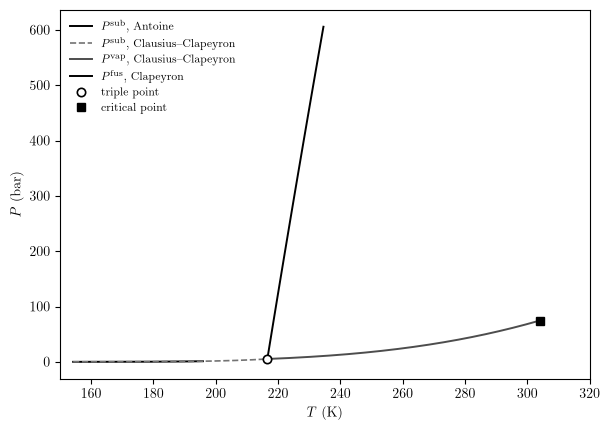

On these axes the melting line is nearly vertical and the sublimation curve is
nearly flat against the axis — it spans 0.0151 to
5.18 bar while the frame runs to 74 bar, so five sixths of the
diagram's interesting structure is compressed into the bottom 7% of it.
The whole solid-vapor region — every state dry ice is ever in — is invisible.


In [9]:
fig, ax = plt.subplots(figsize=(6.2, 4.4))

# Sublimation curve, Antoine, over its fitted range
T = np.linspace(T_Antoine_min, T_Antoine_max, 300)
ax.plot(T, P_antoine(A, B, C, T)/BAR, "-", color="black", lw=1.4,
        label=r"$P^\mathrm{sub}$, Antoine")

# Sublimation curve, Clausius-Clapeyron down from the triple point
T = np.linspace(T_Antoine_min, T_triple, 300)
ax.plot(T, P_CC(H_sub_1, T_triple, P_triple, T)/BAR, "--", color="0.45", lw=1.2,
        label=r"$P^\mathrm{sub}$, Clausius--Clapeyron")

# Vaporization curve, Clausius-Clapeyron up from the triple point
T = np.linspace(T_triple, Tc, 300)
ax.plot(T, P_CC(H_vap_1, T_triple, P_triple, T)/BAR, "-", color="0.30", lw=1.4,
        label=r"$P^\mathrm{vap}$, Clausius--Clapeyron")

# Melting line, integrated Clapeyron up from the triple point
T = np.linspace(T_triple, T_triple + 18, 100)
ax.plot(T, P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)/BAR,
        "-", color="black", lw=1.4, label=r"$P^\mathrm{fus}$, Clapeyron")

ax.plot(T_triple, P_triple/BAR, "o", mfc="white", mec="black", ms=6, mew=1.2,
        label="triple point")
ax.plot(Tc, Pc/BAR, "s", color="black", ms=6, label="critical point")

ax.set_xlabel(r"$T$  (K)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_xlim(150, 320)
ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

print(f"""On these axes the melting line is nearly vertical and the sublimation curve is
nearly flat against the axis — it spans {P_antoine(A,B,C,T_Antoine_min)/BAR:.4f} to
{P_triple/BAR:.2f} bar while the frame runs to {Pc/BAR:.0f} bar, so five sixths of the
diagram's interesting structure is compressed into the bottom {100*P_triple/Pc:.0f}% of it.
The whole solid-vapor region — every state dry ice is ever in — is invisible.""")

### The axes are wrong for the job

A coexistence curve is exponential in $-1/T$, so on linear axes it lies flat against the
abscissa and then turns up sharply. The sublimation curve spans 0.015 to 5.18 bar in a frame
that runs to 74 bar, which puts the entire solid&ndash;vapor region &mdash; every state dry
ice is ever in &mdash; inside the bottom 7% of the plot. This is why Section 7.7 plots
$\ln P^\mathrm{vap}$ against $1/T$, and why the figure below uses a logarithmic pressure axis.

### How good are these approximations, really?

Before redrawing, ask how good the curves are. We have four of them and each
rests on assumptions that we named but never priced:

- the **melting line** used the Clapeyron equation exactly, but needed
  $\Delta_\mathrm{fus}\underline V$ from densities measured 40 K apart;
- the two **Clausius&ndash;Clapeyron curves** assumed an ideal vapor, a negligible liquid
  volume, *and* a temperature-independent $\Delta_\mathrm{sat}\underline H$ &mdash; the last of
  which cannot be true for vaporization, since
  $\Delta_\mathrm{vap}\underline H \to 0$ at the critical point.

Predict that last point before testing it. The vaporization curve carries one
constant $\Delta_\mathrm{vap}\underline H$ from 216 K all the way to $T_c$, where the true
value is zero. It should fail badly near the top.

**It does not.** The next cell shows it holds to about a percent over the whole range, and
then shows why &mdash; which turns out to be the most interesting thing in this notebook, and
not what the setup above would lead you to expect.

In [10]:
from thermo import PengRobinson
from thermo.data import get_compound

# The book's property database carries a Wagner vapor-pressure correlation for CO2,
# fitted to the whole saturation line (217 to 304.1 K). It is the reference curve here:
# an accurate correlation of measurements, against which the approximate curves can be
# priced.
row = get_compound("carbon dioxide")
wa, wb, wc, wd = row["VpA"], row["VpB"], row["VpC"], row["VpD"]
Tc_db, Pc_db = float(row["Tc"]), float(row["Pc"])*BAR


def P_wagner(T):
    """Vapor pressure (Pa) from the pure_property.csv Wagner constants (Eq = 1)."""
    t = 1 - np.asarray(T, dtype=float)/Tc_db
    return Pc_db*np.exp((wa*t + wb*t**1.5 + wc*t**3 + wd*t**6)/(1 - t))


print(f"database CO2: Tc = {Tc_db} K, Pc = {Pc_db/BAR:.1f} bar "
      f"(vs {Tc:.2f} K, {Pc/BAR:.1f} bar above — the same substance, two sources)")

# --- how good is one constant delta_vap_H, over the whole curve? ----------------
T_grid = np.linspace(T_triple, 0.9995*Tc, 400)
P_from_tp = P_CC(H_vap_1, T_triple, P_triple, T_grid)
P_from_cp = P_CC(H_vap_1, Tc, Pc, T_grid)
P_ref = P_wagner(T_grid)

err_tp = 100*(P_from_tp/P_ref - 1)
err_cp = 100*(P_from_cp/P_ref - 1)
print(f"\nClausius-Clapeyron with a single delta_vap_H = {H_vap_1/1000:.1f} kJ/mol, "
      f"{T_triple:.0f} K to Tc:")
print(f"  anchored at the triple point:   mean |error| {np.abs(err_tp).mean():5.2f}%, "
      f"worst {np.abs(err_tp).max():5.2f}%")
print(f"  anchored at the critical point: mean |error| {np.abs(err_cp).mean():5.2f}%, "
      f"worst {np.abs(err_cp).max():5.2f}%")

print("""
That is a surprise. One constant reproduces the entire
vaporization curve of carbon dioxide — from the triple point to the critical point,
across a factor of 14 in pressure — to about a percent. Either the approximations
behind Eq. 7.7-6 are excellent here, or something is canceling. It is the second.""")

# --- what the slope actually measures -------------------------------------------
# Going back to Eq. 7.7-4 WITHOUT approximating, d lnP / d(1/T) = -delta_vap_H/(R dZ)
# with dZ = Z^V - Z^L. Clausius-Clapeyron is the statement dZ = 1. So the slope of
# ln P vs 1/T measures delta_vap_H / dZ, never delta_vap_H by itself.
pr = PengRobinson.from_database("carbon dioxide")


def slope_dH_over_dZ(T, h=0.02):
    """-R d lnP / d(1/T) from the reference curve. This is delta_vap_H / dZ."""
    return -R*(np.log(P_wagner(T + h)) - np.log(P_wagner(T - h))) \
        / (1/(T + h) - 1/(T - h))


print(f"\n{'T (K)':>7}{'Tr':>7}{'dZ':>8}{'dH/dZ':>10}{'dH_vap':>10}")
print(f"{'':7}{'':7}{'':8}{'(kJ/mol)':>10}{'(kJ/mol)':>10}")
for Tp in [T_triple, 240.0, 260.0, 280.0, 295.0, 302.0, 303.5]:
    P = P_wagner(Tp)
    dZ = pr.Z(Tp, P) - pr.Z(Tp, P, phase="liquid")
    s = slope_dH_over_dZ(Tp)
    print(f"{Tp:7.1f}{Tp/Tc_db:7.3f}{dZ:8.4f}{s/1000:10.2f}{s*dZ/1000:10.2f}")

dZ_t = pr.Z(T_triple, P_wagner(T_triple)) \
    - pr.Z(T_triple, P_wagner(T_triple), phase="liquid")
dZ_c = pr.Z(303.5, P_wagner(303.5)) - pr.Z(303.5, P_wagner(303.5), phase="liquid")
print(f"""
There is the cancellation, in the last two columns.

delta_vap_H does what it must: it falls from {slope_dH_over_dZ(T_triple)*dZ_t/1000:.1f} kJ/mol at the triple point
to {slope_dH_over_dZ(303.5)*dZ_c/1000:.1f} kJ/mol at 303.5 K, on its way to exactly zero at Tc, where the two
phases become identical. Over the range we plotted it changes by
{100*(1-slope_dH_over_dZ(303.5)*dZ_c/(slope_dH_over_dZ(T_triple)*dZ_t)):.0f}%.

But dZ collapses at the same time, from {dZ_t:.2f} to {dZ_c:.2f}, because near the critical point
the saturated vapor is nothing like an ideal gas and the saturated liquid is not
negligibly small. And the slope of ln P against 1/T sees only the RATIO. That ratio
sits between {min(slope_dH_over_dZ(np.array([T_triple,240.,260.,280.,295.,302.])))/1000:.1f} and
{max(slope_dH_over_dZ(np.array([T_triple,240.,260.,280.,295.,302.])))/1000:.1f} kJ/mol across the whole
range — nearly constant, which is why the straight line fits.

So the two failures of Eq. 7.7-6 are not independent. Assuming delta_vap_H constant is
badly wrong, assuming dZ = 1 is badly wrong, and the errors run in the same direction
in the quotient and largely cancel. The fit is good for a reason that has nothing to
do with either assumption being satisfied.""")

database CO2: Tc = 304.1 K, Pc = 73.8 bar (vs 304.18 K, 73.8 bar above — the same substance, two sources)

Clausius-Clapeyron with a single delta_vap_H = 16.7 kJ/mol, 217 K to Tc:
  anchored at the triple point:   mean |error|  0.92%, worst  1.85%
  anchored at the critical point: mean |error|  0.95%, worst  1.98%

That is a surprise. One constant reproduces the entire
vaporization curve of carbon dioxide — from the triple point to the critical point,
across a factor of 14 in pressure — to about a percent. Either the approximations
behind Eq. 7.7-6 are excellent here, or something is canceling. It is the second.

  T (K)     Tr      dZ     dH/dZ    dH_vap
                        (kJ/mol)  (kJ/mol)
  216.6  0.712  0.9144     16.91     15.46
  240.0  0.789  0.8267     16.54     13.67
  260.0  0.855  0.7137     16.39     11.70
  280.0  0.921  0.5470     16.49      9.02
  295.0  0.970  0.3459     16.83      5.82
  302.0  0.993  0.1692     17.21      2.91
  303.5  0.998  0.0907     17.39   

## The phase diagram

Now the same four curves on a logarithmic pressure axis, with the Wagner reference curve for
comparison and the regions labeled &mdash; the quantitative counterpart of Figure 7.3-6.

Two annotations do real work. The **1 atm line** is what makes the diagram about
something: follow it left from room temperature and it crosses the sublimation curve, never
the vaporization curve, which is why dry ice behaves as it does. And the
**normal sublimation point** at 194.7 K is where that crossing happens &mdash; $-78.5\,^\circ$C,
the temperature of a dry-ice bath.

*This is not a book figure.* Figure 7.3-6 stays the schematic drawing; this is what the QR
code beside it resolves to. So no PDF is written for print.

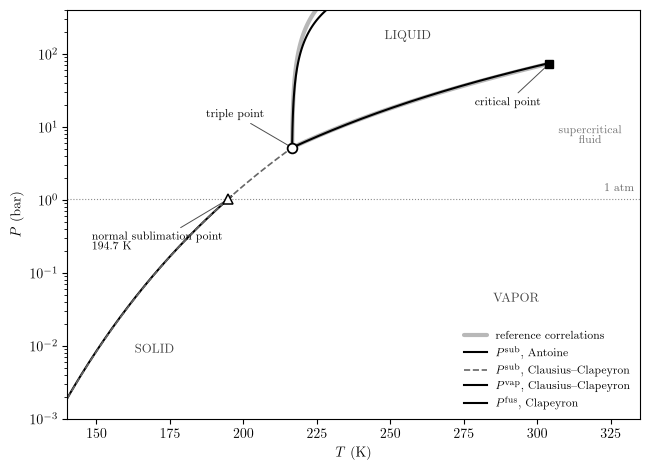

The melting line is the one visible disagreement: ours rises at 35 bar/K
against the reference 47 bar/K, the delta_fus_V estimate showing through. The
two vapor curves and the reference lie on top of one another at this scale — which is
what the percentages above already said, and is why the numbers had to be printed.


In [11]:
fig, ax = plt.subplots(figsize=(6.6, 4.8))

# --- the two reference correlations, drawn first so they sit behind ours
T = np.linspace(T_triple, 0.99995*Tc_db, 400)
ax.plot(T, P_wagner(T)/BAR, "-", color="0.72", lw=3.0, solid_capstyle="round",
        label="reference correlations")
T = np.linspace(T_triple, T_triple + 12, 100)
ax.plot(T, P_melt_ref(T)/BAR, "-", color="0.72", lw=3.0, solid_capstyle="round")

# --- sublimation, Antoine over its fitted range
T = np.linspace(140, T_Antoine_max, 300)
ax.plot(T, P_antoine(A, B, C, T)/BAR, "-", color="black", lw=1.5,
        label=r"$P^\mathrm{sub}$, Antoine")

# --- sublimation, Clausius-Clapeyron from the triple point
T = np.linspace(140, T_triple, 300)
ax.plot(T, P_CC(H_sub_1, T_triple, P_triple, T)/BAR, "--", color="0.40", lw=1.2,
        label=r"$P^\mathrm{sub}$, Clausius--Clapeyron")

# --- vaporization, Clausius-Clapeyron from the triple point
T = np.linspace(T_triple, Tc, 300)
ax.plot(T, P_CC(H_vap_1, T_triple, P_triple, T)/BAR, "-", color="black", lw=1.5,
        label=r"$P^\mathrm{vap}$, Clausius--Clapeyron")

# --- melting, integrated Clapeyron from the triple point
T = np.linspace(T_triple, T_triple + 12, 100)
ax.plot(T, P_clapeyron(T_triple, P_triple, T, delta_fus_H, delta_fus_V)/BAR,
        "-", color="black", lw=1.5, label=r"$P^\mathrm{fus}$, Clapeyron")

# --- the two fixed points
ax.plot(T_triple, P_triple/BAR, "o", mfc="white", mec="black", ms=7, mew=1.3, zorder=5)
ax.plot(Tc, Pc/BAR, "s", color="black", ms=6, zorder=5)

# --- 1 atm, and where it crosses the sublimation curve
T_sub_1atm = T_antoine(A, B, C, ATM)
ax.axhline(ATM/BAR, color="0.55", lw=0.8, ls=":")
ax.plot(T_sub_1atm, ATM/BAR, "^", mfc="white", mec="black", ms=7, mew=1.1, zorder=5)

ax.set_xlabel(r"$T$  (K)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_yscale("log")
ax.set_xlim(140, 335)
ax.set_ylim(1e-3, 4e2)

# --- annotations
ax.annotate("triple point", xy=(T_triple, P_triple/BAR), xytext=(-62, 22),
            textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.annotate("critical point", xy=(Tc, Pc/BAR), xytext=(-30, -30),
            textcoords="offset points", fontsize=8, ha="center",
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.annotate(f"normal sublimation point\n{T_sub_1atm:.1f} K", xy=(T_sub_1atm, ATM/BAR),
            xytext=(-98, -36), textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))
ax.text(333, ATM/BAR*1.3, "1 atm", fontsize=8, color="0.4", ha="right")

ax.text(163, 8e-3, "SOLID", fontsize=9, color="0.25")
ax.text(248, 1.6e2, "LIQUID", fontsize=9, color="0.25")
ax.text(285, 4e-2, "VAPOR", fontsize=9, color="0.25")
ax.text(318, 6e0, "supercritical\nfluid", fontsize=8, color="0.45", ha="center")

ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

print(f"""The melting line is the one visible disagreement: ours rises at {slope_ours/BAR:.0f} bar/K
against the reference {slope_ref/BAR:.0f} bar/K, the delta_fus_V estimate showing through. The
two vapor curves and the reference lie on top of one another at this scale — which is
what the percentages above already said, and is why the numbers had to be printed.""")

## What this diagram shows

**The vocabulary is universal; the numbers are not.** Figure 7.3-6 is right about every
feature: three curves, one triple point, one critical point, the vaporization curve stopping
and the melting curve not. Carbon dioxide has all of them. What the schematic cannot give you
is that CO$_2$'s triple point sits at 5.18 bar, and that single number explains an everyday
observation the schematic is silent about.

**Read the 1 atm line.** It crosses the sublimation curve at 194.7 K and never crosses the
vaporization curve at all. So at atmospheric pressure carbon dioxide has no liquid state: cool
the gas and you get a solid, warm the solid and you get a gas. That is why dry ice sublimes,
why it is $-78.5\,^\circ$C, and why liquid CO$_2$ turns up only in pressurized vessels.
Water's triple point is at 0.006 bar, *below* atmospheric, which is why water does the ordinary
thing and CO$_2$ does not. One number, on one axis.

**Three relations, three different jobs.** The melting line needed the Clapeyron equation used
exactly, because neither phase is a vapor and so nothing could be neglected. The two curves
ending in a vapor could use Clausius&ndash;Clapeyron. The Antoine equation needed no
thermodynamics at all &mdash; it is a fit, and over its fitted range it is the most accurate
curve on the plot. Knowing which tool the situation permits is the skill; the three are not
interchangeable.

**The approximate curve is far better than it has any right to be, and the reason is a
cancellation.** This is the notebook's real result, and it is not what you would predict. One
constant $\Delta_\mathrm{vap}\underline H$ reproduces the whole vaporization curve to about a
percent &mdash; even though the true $\Delta_\mathrm{vap}\underline H$ falls from 15.5 kJ/mol
at the triple point to zero at the critical point, a 100% change. It works because the slope
of $\ln P^\mathrm{vap}$ against $1/T$ never measures
$\Delta_\mathrm{vap}\underline H$; it measures
$\Delta_\mathrm{vap}\underline H/\Delta Z$. And $\Delta Z = Z^V - Z^L$ collapses from 0.91 to
0.09 over the same interval, for the same physical reason. The quotient stays within a few
percent of 16.5 kJ/mol from end to end.

Two lessons follow, and the second is the durable one:

1. *Do not read the success of a fit as evidence that its assumptions hold.* Both
   approximations behind Eq. 7.7-6 are badly violated here. The curve is accurate anyway.
2. *Know what your slope actually measures.* Illustration 7.7-1 reads the straightness of
   Figure 7.7-1 as showing $\Delta_\mathrm{vap}\underline H$ is nearly constant. Over that
   narrow range ($T_r = 0.47$ to $0.68$, where $\Delta Z \approx 1$) the reading is nearly
   right, and Problem 7.80 shows how the residuals expose the remaining 12%. Here, at
   $T_r \to 1$, the same straightness would be an entirely wrong inference. The
   quantity a semi-log slope returns is a ratio, and $\Delta Z \approx 1$ is a
   *separate* assumption that has to be checked, not a property of the plot.

**And every pressure here was tabulated in bar.** Three constants in the earlier version of
this notebook were converted as though they were atmospheres. Each error was 1.3%, none
changed the shape of anything, and all three were invisible until a computed number was
checked against something known independently. Correlation constants carry a units convention
and a logarithm base, and neither is recoverable from the numbers themselves.

### Things to try

1. **A CO$_2$ cylinder for a home carbonation machine.** The cylinder holds 410 g of carbon
   dioxide in 0.64 L and sits at room temperature, 298 K. Compute the molar volume, and use
   the diagram plus a Peng&ndash;Robinson calculation to decide what is inside: gas, liquid,
   both, or supercritical fluid. Then find the pressure. Two checks &mdash; how
   does your answer compare with the vapor pressure at 298 K, and what would change if the
   cylinder warmed to $35\,^\circ$C? (`mechanical_stability_CO2.ipynb` has the
   root-selection machinery; note that 298 K is below $T_c$, so the equation of state alone
   does not tell you which phase you are in.)

2. **Where does the melting line reach 1 kbar?** Extend the Clapeyron melting line and read
   off the temperature. Then ask how much you should trust it: $\Delta_\mathrm{fus}\underline
   H$ and $\Delta_\mathrm{fus}\underline V$ were both taken constant, and one of them came
   from densities measured 40 K apart. Compare against the Jäger&ndash;Span melting curve.

3. **Fit the Antoine equation to the sublimation data yourself**, then extrapolate it to the
   triple point. It lands about 2% low above. Is that the fit's fault or the extrapolation's?
   Refit using only the coldest half of the range and see which way the error moves.

4. **Anchor the vaporization curve at the critical point instead** and reproduce the second
   row of the comparison table. Then try anchoring it at 260 K, halfway along, using the
   reference curve for the pressure there. Which anchor gives the smallest *worst-case* error
   over the whole range, and is that the same as the smallest average error?

5. **Do it for water.** Water's triple point is 273.16 K at 611.7 Pa and its critical point
   is 647.1 K at 220.6 bar. Build the same diagram and explain, from the position of the 1 atm
   line, why water has an ordinary liquid range and CO$_2$ does not. Then look at the slope of
   the melting line: for water it is *negative*, because
   $\Delta_\mathrm{fus}\underline V < 0$. Which term in the Clapeyron equation carries that
   sign, and what does it predict about ice under pressure?

6. **`N2_phases.ipynb`** builds this diagram for nitrogen and makes the other choice at both
   places where this notebook had to decide something. Read it next.